# 🧠 Grad-CAM++ XAI pada Test Set (CNN Iftikhar 2025)

**Referensi Paper:**
> Chattopadhyay et al. (2018) — *Grad-CAM++: Improved Visual Explanations for Deep Convolutional Networks*
> Mahesh T R et al. (2024) — *An XAI-enhanced EfficientNetB0 framework for precision brain tumor detection*, Journal of Neuroscience Methods.
> Muhammad D & Bendechache M (2025) — *More than just a heatmap: elevating XAI with rigorous evaluation metrics*, Front. Med. Technol. 7:1674343.

**Pipeline:**
| # | Tahap | Keterangan |
|---|---|---|
| 1 | Setup & Konfigurasi | Library, path, konfigurasi |
| 2 | Load Dataset | Load citra test set |
| 3 | Load Model CNN | Arsitektur CNN Iftikhar 2025 |
| 4 | GradModel | Model bantu Grad-CAM++ |
| 5 | Grad-CAM & Grad-CAM++ | Core XAI functions |
| 6 | Visualisasi per Kelas | Heatmap per kelas (FINAL_5 style) |
| 7 | Benar vs Salah | Grid prediksi benar & salah |
| 8 | Grid Sampel | 4 contoh per kelas |
| 9 | Confusion Matrix | Annotasi TP/TN/FP/FN |
| 10 | Metrik Statistik | Acc, Prec, Recall, F1 |
| 11 | Ekspor Saliency .npy | Untuk pipeline XAlign (NB8) |
| 12 | XAlign | WRO, BAS, DP, XAlign per gambar |
| 13 | Sensitivity Analysis | Variasi bobot XAlign |
| 14 | Ringkasan JSON | xai_summary.json |


## 1. Setup & Konfigurasi

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [9]:
!pip install tensorflow opencv-python-headless matplotlib numpy Pillow tqdm scikit-learn seaborn scipy -q

In [10]:
import os, re, json, cv2, glob, csv, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
from scipy.spatial.distance import directed_hausdorff

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

print(f'✅ TensorFlow : {tf.__version__}')
print(f'   GPU        : {tf.config.list_physical_devices("GPU")}')
print(f'   OpenCV     : {cv2.__version__}')


✅ TensorFlow : 2.20.0
   GPU        : []
   OpenCV     : 4.13.0


## 2. Konfigurasi Path & Parameter

In [11]:
# ─── Path Dataset ─────────────────────────────────────────────────────────────
TEST_DIR = '/content/drive/MyDrive/Tugas Akhir/FINAL_dataset_GC_val_test/test'
VAL_DIR  = '/content/drive/MyDrive/Tugas Akhir/FINAL_dataset_GC_val_test/val'

# ─── Path Model Terlatih (CNN Iftikhar 2025) ──────────────────────────────────
MODEL_PATH = '/content/drive/MyDrive/Tugas Akhir/CNN Gradcam/FINAL_EXP_CNN_GC_val_test_ORI/best_model_grid_search.keras'

# ─── Output Folder (sesuai struktur FINAL_5) ──────────────────────────────────
OUTPUT_DIR = '/content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test'
PROSES_DIR = os.path.join(OUTPUT_DIR, 'proses')
XAI_DIR    = os.path.join(PROSES_DIR, 'gradcam_xai')
XALIGN_DIR = os.path.join(XAI_DIR, 'xalign')
SALIENCY_NPY_DIR = os.path.join(XAI_DIR, 'saliency_npy')
METADATA_CSV     = os.path.join(XAI_DIR, 'metadata_test.csv')

for d in [OUTPUT_DIR, PROSES_DIR, XAI_DIR, XALIGN_DIR, SALIENCY_NPY_DIR]:
    os.makedirs(d, exist_ok=True)

# ─── [PAIR] Ground-truth mask ─────────────────────────────────────────────────
PAIR_BASE_DIR      = '/content/drive/MyDrive/Tugas Akhir/FINAL_dataset_GC_val_test'
PAIR_TEST_DIR      = os.path.join(PAIR_BASE_DIR, 'test',  'tumor')
PAIR_VAL_DIR       = os.path.join(PAIR_BASE_DIR, 'val',   'tumor')
PAIR_TEST_MASK_DIR = os.path.join(PAIR_TEST_DIR, 'masks')
PAIR_VAL_MASK_DIR  = os.path.join(PAIR_VAL_DIR,  'masks')
IMAGE_PATTERN      = r'^image_tumor_mask__(.+)_CT_s(.+)\.png$'
MASK_TEMPLATE      = 'mask_tumor__{patient_id}_CT_m{slice_id}.png'

PAIR_OUTPUT_DIR = os.path.join(OUTPUT_DIR, 'XAI_prep')
os.makedirs(PAIR_OUTPUT_DIR, exist_ok=True)

# ─── Konfigurasi Model CNN Iftikhar 2025 ──────────────────────────────────────
IMG_SIZE        = (224, 224)
NUM_CLASSES     = 2
CLASS_NAMES     = ['no_tumor', 'tumor']
LAST_CONV_LAYER = 'conv6'   # layer conv terakhir CNN Iftikhar
EPS             = 1e-7
BEST_DROPOUT    = 0.3        # ← sesuaikan dengan hasil grid search Anda

# ─── XAlign bobot (Muhammad & Bendechache 2025, Eq. 17) ──────────────────────
XALIGN_ALPHA = 0.5
XALIGN_BETA  = 0.4
XALIGN_GAMMA = 0.1

print('✅ Konfigurasi berhasil dimuat.')
print(f'   Model        : {MODEL_PATH}')
print(f'   XAI output   : {XAI_DIR}')
print(f'   XAlign output: {XALIGN_DIR}')
for p, name in [(PAIR_TEST_DIR,'PAIR_TEST_DIR'),(PAIR_TEST_MASK_DIR,'PAIR_TEST_MASK_DIR')]:
    s = '✅' if os.path.exists(p) else '⚠️  TIDAK DITEMUKAN'
    print(f'   {s}  {name}')

✅ Konfigurasi berhasil dimuat.
   Model        : /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/FINAL_EXP_CNN_GC_val_test_ORI/best_model_grid_search.keras
   XAI output   : /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai
   XAlign output: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign
   ✅  PAIR_TEST_DIR
   ✅  PAIR_TEST_MASK_DIR


## 3. Load Dataset & Fungsi Utilitas

In [12]:
def load_image_as_array(image_path, target_size=(224, 224)):
    """Load citra ke numpy array, normalisasi ke [0,1] untuk CNN."""
    img = Image.open(image_path)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    if img.size != (target_size[1], target_size[0]):
        img = img.resize((target_size[1], target_size[0]), Image.LANCZOS)
    arr = np.array(img, dtype=np.float32)
    if arr.max() > 1.0:
        arr = arr / 255.0
    return arr

def preprocess_to_batch(image_path):
    """Returns (1, H, W, 3) float32 [0,1]."""
    return np.expand_dims(load_image_as_array(image_path, IMG_SIZE), 0)

def load_test_images(test_dir, class_names, img_size=(224,224), max_per_class=100):
    """Load test images ke list. Returns imgs (uint8 RGB), labels, paths."""
    imgs, labels, paths = [], [], []
    for cls_idx, cls_name in enumerate(class_names):
        cls_dir = os.path.join(test_dir, cls_name)
        if not os.path.isdir(cls_dir):
            print(f'  ⚠️  Skip: {cls_dir}'); continue
        img_paths = sorted(
            p for ext in ('*.png','*.jpg','*.jpeg')
            for p in glob.glob(os.path.join(cls_dir, ext))
        )[:max_per_class]
        for fp in img_paths:
            raw = cv2.imread(fp)
            if raw is None: continue
            img_rgb = cv2.cvtColor(cv2.resize(raw, img_size), cv2.COLOR_BGR2RGB)
            imgs.append(img_rgb)
            labels.append(cls_idx)
            paths.append(fp)
        print(f'  {cls_name}: {len(img_paths)} gambar dimuat')
    return imgs, labels, paths

test_imgs, test_labels, test_paths = load_test_images(TEST_DIR, CLASS_NAMES, IMG_SIZE, max_per_class=100)
print(f'\nTotal test images: {len(test_imgs)}')

  no_tumor: 42 gambar dimuat
  tumor: 100 gambar dimuat

Total test images: 142


## 4. Load Model CNN Iftikhar 2025

In [13]:
def build_cnn(dropout_rate=0.3, num_classes=2):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name='input_image')
    x = inputs
    for filters, name in zip([8,16,32,64,128], ['conv1','conv2','conv3','conv4','conv5']):
        x = layers.Conv2D(filters, (3,3), padding='same', activation='relu', name=name)(x)
        x = layers.MaxPooling2D((2,2), name=f'pool{name[-1]}')(x)
    x = layers.Conv2D(256, (3,3), padding='same', activation='relu', name='conv6')(x)
    x = layers.BatchNormalization(name='batchnorm')(x)
    x = layers.AveragePooling2D((2,2), name='avgpool')(x)
    x = layers.Flatten(name='flatten')(x)
    x = layers.Dropout(dropout_rate, name='dropout1')(x)
    x = layers.Dense(512, activation='relu', name='dense1')(x)
    x = layers.Dropout(dropout_rate, name='dropout2')(x)
    x = layers.Dense(512, activation='relu', name='dense2')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return keras.Model(inputs, outputs, name='CNN_Iftikhar2025')

print('⏳ Memuat model CNN terlatih...')
if os.path.exists(MODEL_PATH):
    model = keras.models.load_model(MODEL_PATH)
    print(f'✅ Model dimuat dari: {MODEL_PATH}')
else:
    print(f'⚠️  Model tidak ditemukan, rebuild dari scratch (hanya untuk demo).')
    model = build_cnn(dropout_rate=BEST_DROPOUT, num_classes=NUM_CLASSES)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

⏳ Memuat model CNN terlatih...
✅ Model dimuat dari: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/FINAL_EXP_CNN_GC_val_test_ORI/best_model_grid_search.keras


Model: "CNN_Iftikhar2025"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 224, 224, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 112, 112, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 112, 112, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 56, 56, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 56, 56, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool3 (MaxPooling2D)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool4 (MaxPooling2D)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv6 (Conv2D)                  │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batchnorm (BatchNormalization)  │ (None, 7, 7, 256)      │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool (AveragePooling2D)      │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,514,232 (21.04 MB)

 Trainable params: 1,837,906 (7.01 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 3,675,814 (14.02 MB)

## 5. Bangun GradModel (Grad-CAM++)

In [14]:
def build_grad_model(base_model, conv_layer_name=LAST_CONV_LAYER):
    """Dual-output model: [conv features, logit sebelum softmax]."""
    conv_out     = base_model.get_layer(conv_layer_name).output
    output_layer = base_model.get_layer('output')
    dense2_out   = base_model.get_layer('dense2').output
    logit_layer  = layers.Dense(output_layer.units, activation='linear',
                                use_bias=True, name='logit_output')
    logits       = logit_layer(dense2_out)
    grad_model   = keras.Model(inputs=base_model.inputs,
                                outputs=[conv_out, logits], name='GradModel')
    logit_layer.set_weights(output_layer.get_weights())
    return grad_model

grad_model = build_grad_model(model, LAST_CONV_LAYER)
print('✅ GradModel dibangun.')
print(f'   Output [0] conv6 features : {grad_model.outputs[0].shape}')
print(f'   Output [1] logits         : {grad_model.outputs[1].shape}')

# Verifikasi konsistensi logit ↔ softmax
_dummy         = np.zeros((1, *IMG_SIZE, 3), dtype=np.float32)
_sm_preds      = model.predict(_dummy, verbose=0)[0]
_, _logits_raw = grad_model.predict(_dummy, verbose=0)
_lv = _logits_raw[0]; _lv -= _lv.max()
_sm_from_logit = np.exp(_lv) / np.exp(_lv).sum()
_max_diff      = np.abs(_sm_preds - _sm_from_logit).max()
assert _max_diff < 1e-4, f'⛔ Logit tidak konsisten! Δ={_max_diff:.2e}'
print(f'   Verifikasi logit ↔ softmax: ✅  (max_diff={_max_diff:.2e})')

✅ GradModel dibangun.
   Output [0] conv6 features : (None, 7, 7, 256)
   Output [1] logits         : (None, 2)
   Verifikasi logit ↔ softmax: ✅  (max_diff=4.55e-24)


## 6. Implementasi Grad-CAM & Grad-CAM++

In [15]:
def compute_gradcam(img_array, class_idx, eps=EPS):
    """Grad-CAM — Selvaraju et al. (2016). Input [0,1] float32."""
    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        conv_out, logits = grad_model(img_tensor, training=False)
        tape.watch(conv_out)
        score = logits[:, class_idx]
    grads   = tape.gradient(score, conv_out)
    pooled  = tf.reduce_mean(grads, axis=(0,1,2)).numpy()
    conv_np = conv_out[0].numpy()
    cam     = np.einsum('hwk,k->hw', conv_np, pooled)
    cam     = np.maximum(cam, 0)
    lo, hi  = cam.min(), cam.max()
    return ((cam - lo) / (hi - lo + eps)).astype(np.float32), conv_np

def compute_gradcam_plus_plus(img_array, class_idx, eps=EPS):
    """Grad-CAM++ — Chattopadhyay et al. (2018), Eq. 5,10,19,20."""
    img_tensor = tf.cast(img_array, tf.float32)
    with tf.GradientTape() as tape:
        conv_out, logits = grad_model(img_tensor, training=False)
        tape.watch(conv_out)
        score = logits[:, class_idx]
    grads      = tape.gradient(score, conv_out)
    grads_sq   = grads ** 2
    grads_cube = grads ** 3
    A_sum      = tf.reduce_sum(conv_out, axis=(1,2), keepdims=True)
    denom      = 2.0 * grads_sq + A_sum * grads_cube
    alpha      = tf.where(tf.abs(denom) > eps, grads_sq / (denom + eps), tf.zeros_like(denom))
    weights    = tf.reduce_sum(alpha * tf.nn.relu(grads), axis=(1,2), keepdims=True)
    cam        = tf.nn.relu(tf.reduce_sum(weights * conv_out, axis=-1))
    cam_np     = cam[0].numpy()
    lo, hi     = cam_np.min(), cam_np.max()
    return ((cam_np - lo) / (hi - lo + eps)).astype(np.float32), conv_out[0].numpy()

def superimpose_heatmap(heatmap, original_img_rgb, alpha=0.5, colormap=cv2.COLORMAP_JET):
    """Overlay heatmap ke gambar asli (RGB uint8). Heatmap float[0,1] atau uint8."""
    h, w = original_img_rgb.shape[:2]
    heatmap_resized = cv2.resize(heatmap if heatmap.dtype==np.float32 else heatmap/255.0, (w,h))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    colored = cv2.applyColorMap(heatmap_uint8, colormap)
    colored = cv2.cvtColor(colored, cv2.COLOR_BGR2RGB)
    return np.uint8(cv2.addWeighted(original_img_rgb.astype(np.float32), 1-alpha,
                                     colored.astype(np.float32), alpha, 0))

def gradcam_single(img_rgb, target_class=None, alpha=0.5, use_pp=True):
    """Proses 1 gambar → (heatmap, overlay, pred_idx, pred_prob). img_rgb uint8."""
    img_batch = np.expand_dims(img_rgb.astype(np.float32)/255.0, 0)
    preds = model.predict(img_batch, verbose=0)[0]
    pred_idx  = int(np.argmax(preds))
    pred_prob = float(preds[pred_idx])
    ci = target_class if target_class is not None else pred_idx
    fn = compute_gradcam_plus_plus if use_pp else compute_gradcam
    cam, _ = fn(img_batch, ci)
    cam_224 = cv2.resize(cam, IMG_SIZE)
    overlay = superimpose_heatmap(cam_224, img_rgb, alpha=alpha)
    return cam_224, overlay, pred_idx, pred_prob

print('✅ Fungsi Grad-CAM & Grad-CAM++ siap.')

✅ Fungsi Grad-CAM & Grad-CAM++ siap.


## 7. Prediksi Model pada Seluruh Test Images

In [16]:
X_test_arr = np.array([img.astype(np.float32)/255.0 for img in test_imgs])

BATCH = 32
preds_prob = []
for i in range(0, len(X_test_arr), BATCH):
    preds_prob.append(model.predict(X_test_arr[i:i+BATCH], verbose=0))
preds_prob = np.concatenate(preds_prob, axis=0)
y_pred = np.argmax(preds_prob, axis=1)
y_true = np.array(test_labels)

print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

correct_idx = {c: [] for c in range(NUM_CLASSES)}
wrong_idx   = {c: [] for c in range(NUM_CLASSES)}
for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if yt == yp: correct_idx[yt].append(i)
    else:        wrong_idx[yt].append(i)

tp_idx, tn_idx, fp_idx, fn_idx = [], [], [], []
for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if   yt==1 and yp==1: tp_idx.append(i)
    elif yt==0 and yp==0: tn_idx.append(i)
    elif yt==0 and yp==1: fp_idx.append(i)
    elif yt==1 and yp==0: fn_idx.append(i)

print('\nDistribusi Kuadran:')
print(f'  TP: {len(tp_idx):4d}  |  TN: {len(tn_idx):4d}  |  FP: {len(fp_idx):4d}  |  FN: {len(fn_idx):4d}')

=== Classification Report ===
              precision    recall  f1-score   support

    no_tumor       0.39      0.76      0.52        42
       tumor       0.83      0.50      0.62       100

    accuracy                           0.58       142
   macro avg       0.61      0.63      0.57       142
weighted avg       0.70      0.58      0.59       142


Distribusi Kuadran:
  TP:   50  |  TN:   32  |  FP:   10  |  FN:   50


## 8. Visualisasi Grad-CAM++ per Kelas (Prediksi Benar)

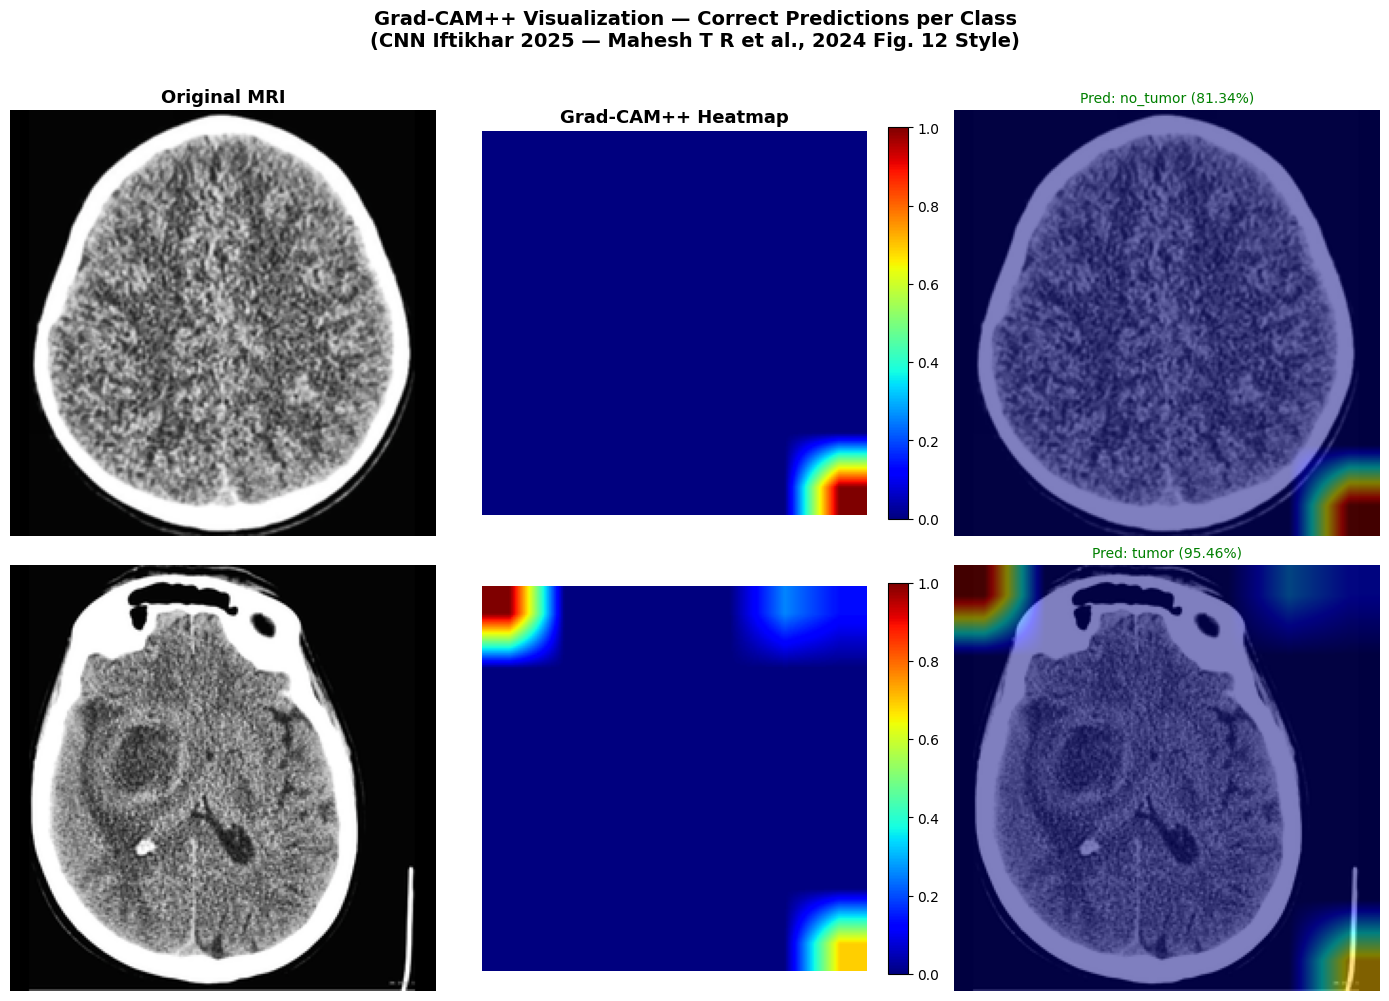

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/gradcam_correct_per_class.png


In [17]:
N_COLS = 3
N_ROWS = NUM_CLASSES

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, 5*N_ROWS))
if N_ROWS == 1: axes = axes[np.newaxis, :]

col_titles = ['Original CT Scan', 'Grad-CAM++ Heatmap', 'Overlay (Superimposed)']
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=13, fontweight='bold')

for row, (cls_idx, cls_name) in enumerate(zip(range(NUM_CLASSES), CLASS_NAMES)):
    if not correct_idx[cls_idx]:
        print(f'⚠️  Tidak ada prediksi benar untuk kelas {cls_name}'); continue
    sample_i  = correct_idx[cls_idx][0]
    img_rgb   = test_imgs[sample_i]
    heatmap, overlay, pred_idx, pred_prob = gradcam_single(img_rgb)
    pred_label = CLASS_NAMES[pred_idx]

    axes[row,0].imshow(img_rgb)
    axes[row,0].set_ylabel(f'True: {cls_name}', fontsize=11, rotation=90, labelpad=10)
    axes[row,0].axis('off')

    im = axes[row,1].imshow(cv2.resize(heatmap, IMG_SIZE), cmap='jet', vmin=0, vmax=1)
    plt.colorbar(im, ax=axes[row,1], fraction=0.046)
    axes[row,1].axis('off')

    axes[row,2].imshow(overlay)
    axes[row,2].set_title(f'Pred: {pred_label} ({pred_prob:.2%})', fontsize=10, color='green')
    axes[row,2].axis('off')

plt.suptitle('Grad-CAM++ Visualization — Correct Predictions per Class\n(CNN Iftikhar 2025 — Mahesh T R et al., 2024 Fig. 12 Style)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = os.path.join(XAI_DIR, 'gradcam_correct_per_class.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {out_path}')

## 9. Grad-CAM++: Prediksi Benar vs Salah

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/gradcam_correct_vs_wrong.png


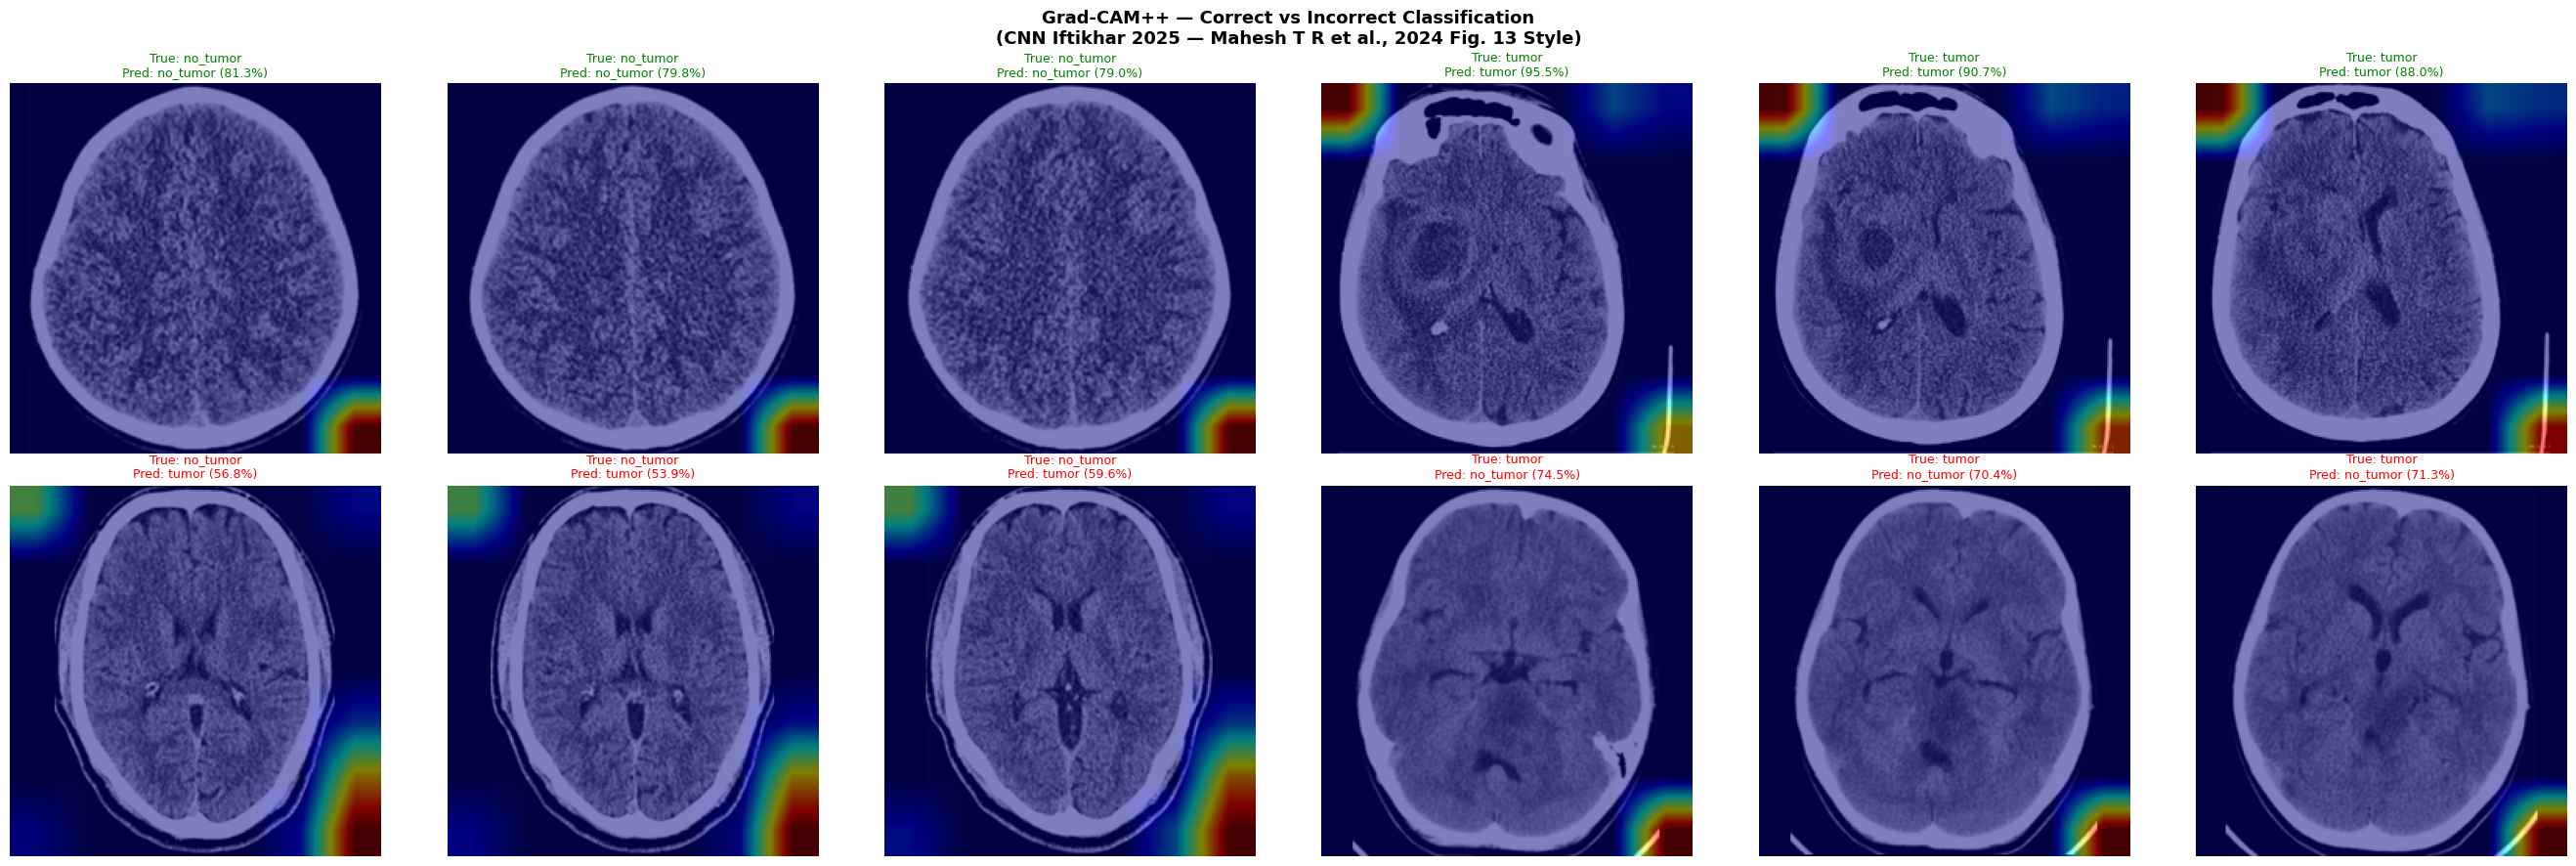

In [18]:
def plot_correct_wrong(correct_indices, wrong_indices, n_each=3, save_path=None):
    correct_pool, wrong_pool = [], []
    for cls_idx in range(NUM_CLASSES):
        correct_pool.extend(correct_indices.get(cls_idx, [])[:n_each])
        wrong_pool.extend(wrong_indices.get(cls_idx, [])[:n_each])
    correct_pool = correct_pool[:n_each*NUM_CLASSES]
    wrong_pool   = wrong_pool[:n_each*NUM_CLASSES]
    n_cols = max(len(correct_pool), len(wrong_pool), 1)
    fig, axes = plt.subplots(2, n_cols, figsize=(4.5*n_cols, 9))
    if n_cols == 1: axes = axes[:, np.newaxis]
    for row_i, (pool, label) in enumerate(zip([correct_pool, wrong_pool],
                                               ['✅ Correct Prediction','❌ Incorrect Prediction'])):
        axes[row_i,0].set_ylabel(label, fontsize=11, fontweight='bold', rotation=90)
        for col_i in range(n_cols):
            ax = axes[row_i, col_i]
            if col_i >= len(pool): ax.axis('off'); continue
            idx     = pool[col_i]
            img_rgb = test_imgs[idx]
            true_lbl = CLASS_NAMES[test_labels[idx]]
            _, overlay, pred_i, pred_prob = gradcam_single(img_rgb)
            pred_lbl = CLASS_NAMES[pred_i]
            color = 'green' if pred_lbl == true_lbl else 'red'
            ax.imshow(overlay)
            ax.set_title(f'True: {true_lbl}\nPred: {pred_lbl} ({pred_prob:.1%})', fontsize=9, color=color)
            ax.axis('off')
    plt.suptitle('Grad-CAM++ — Correct vs Incorrect Classification\n(CNN Iftikhar 2025 — Mahesh T R et al., 2024 Fig. 13 Style)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches='tight'); print(f'✅ Disimpan: {save_path}')
    plt.show()

plot_correct_wrong(correct_idx, wrong_idx, n_each=3,
                   save_path=os.path.join(XAI_DIR, 'gradcam_correct_vs_wrong.png'))

## 10. Grad-CAM++ Grid — 4 Contoh per Kelas

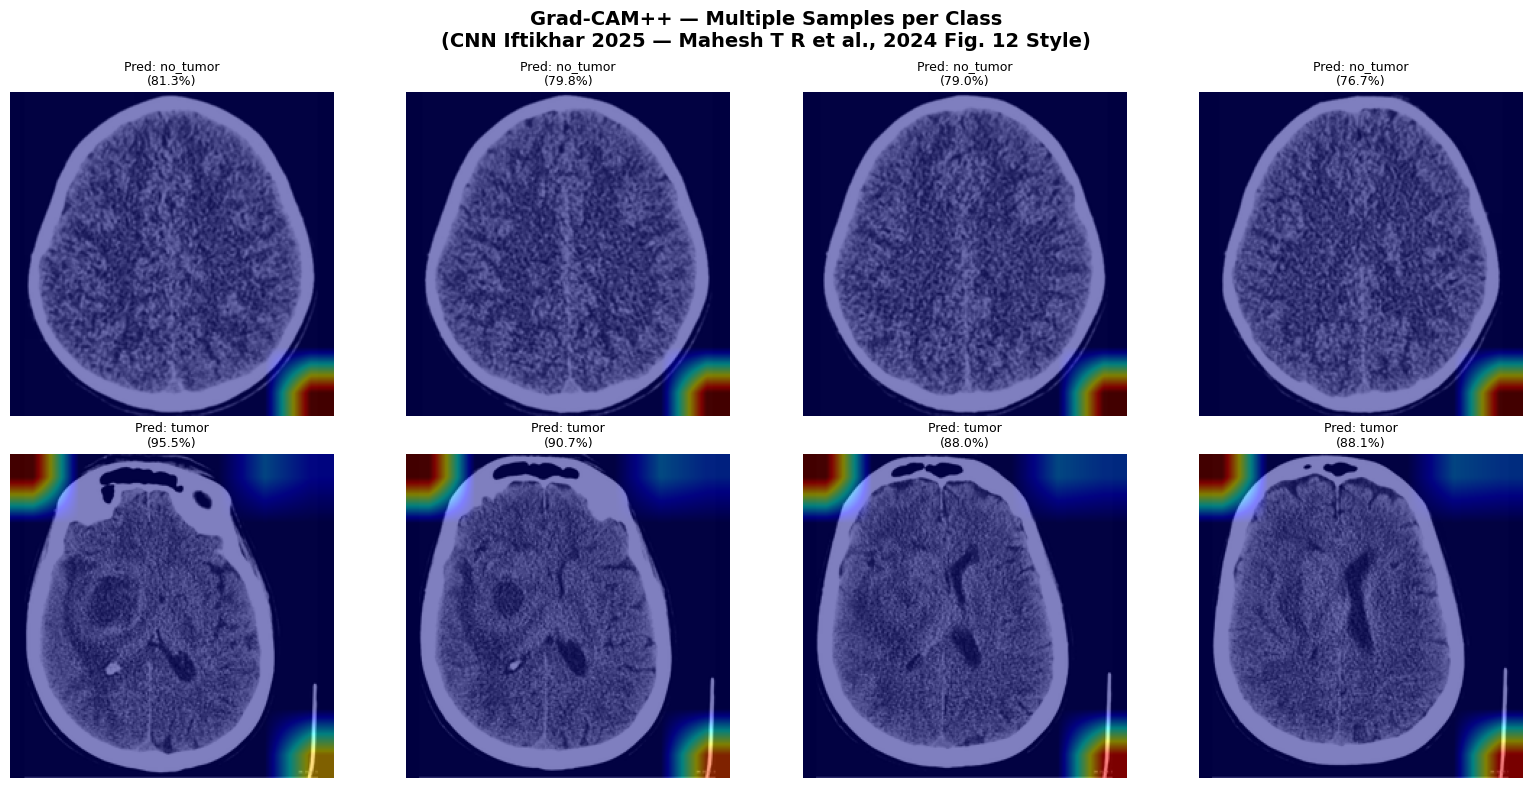

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/gradcam_grid_all_classes.png


In [19]:
N_SAMPLES_PER_CLASS = 4

fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES_PER_CLASS, figsize=(4*N_SAMPLES_PER_CLASS, 4*NUM_CLASSES))
if NUM_CLASSES == 1: axes = axes[np.newaxis, :]

for row, (cls_idx, cls_name) in enumerate(zip(range(NUM_CLASSES), CLASS_NAMES)):
    pool = correct_idx[cls_idx][:N_SAMPLES_PER_CLASS]
    axes[row,0].set_ylabel(cls_name.upper(), fontsize=12, fontweight='bold', rotation=90)
    for col, sample_i in enumerate(pool):
        _, overlay, pred_idx, pred_prob = gradcam_single(test_imgs[sample_i])
        axes[row,col].imshow(overlay)
        axes[row,col].set_title(f'Pred: {CLASS_NAMES[pred_idx]}\n({pred_prob:.1%})', fontsize=9)
        axes[row,col].axis('off')
    for col in range(len(pool), N_SAMPLES_PER_CLASS):
        axes[row,col].axis('off')

plt.suptitle('Grad-CAM++ — Multiple Samples per Class\n(CNN Iftikhar 2025 — Mahesh T R et al., 2024 Fig. 12 Style)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
out_path = os.path.join(XAI_DIR, 'gradcam_grid_all_classes.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Disimpan: {out_path}')

## 11. Confusion Matrix & Analisis Kuadran TP/TN/FP/FN

Kuadran: TP=50  TN=32  FP=10  FN=50


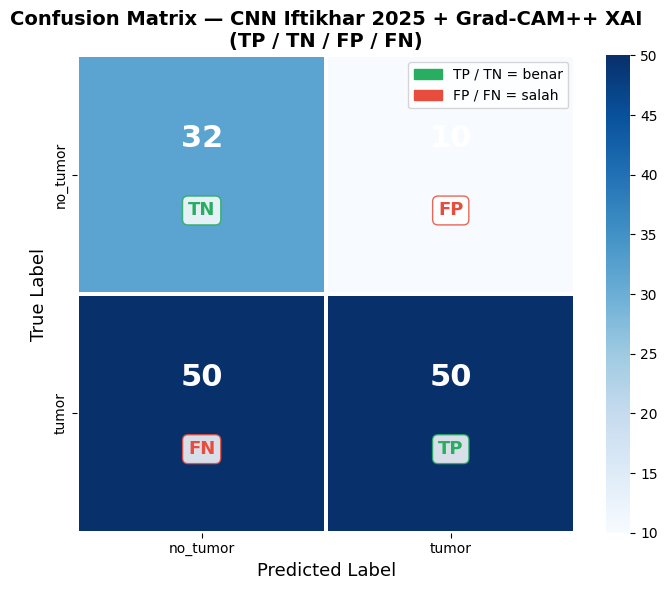

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/confusion_matrix_TP_TN_FP_FN.png
✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xai_confusion_matrix.png


In [20]:
# ── Build kuadran indeks ─────────────────────────────────────────────────────
tp_idx, tn_idx, fp_idx, fn_idx = [], [], [], []
for i, (yt, yp) in enumerate(zip(y_true, y_pred)):
    if   yt==1 and yp==1: tp_idx.append(i)
    elif yt==0 and yp==0: tn_idx.append(i)
    elif yt==0 and yp==1: fp_idx.append(i)
    elif yt==1 and yp==0: fn_idx.append(i)

print(f'Kuadran: TP={len(tp_idx)}  TN={len(tn_idx)}  FP={len(fp_idx)}  FN={len(fn_idx)}')

# ── Confusion Matrix dengan anotasi TP/TN/FP/FN (FINAL_6 style) ─────────────
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=1.5, linecolor='white')

labels_quad  = [['TN','FP'],['FN','TP']]
colors_quad  = [['#27AE60','#E74C3C'],['#E74C3C','#27AE60']]
for row_i in range(2):
    for col_i in range(2):
        count = cm[row_i, col_i]
        quad  = labels_quad[row_i][col_i]
        color = colors_quad[row_i][col_i]
        ax.text(col_i+0.5, row_i+0.35, str(count),
                ha='center', va='center', fontsize=22,
                fontweight='bold', color='white')
        ax.text(col_i+0.5, row_i+0.65, quad,
                ha='center', va='center', fontsize=13,
                fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          alpha=0.85, edgecolor=color))

ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix — CNN Iftikhar 2025 + Grad-CAM++ XAI\n(TP / TN / FP / FN)',
             fontsize=14, fontweight='bold')
ax.legend(handles=[
    mpatches.Patch(color='#27AE60', label='TP / TN = benar'),
    mpatches.Patch(color='#E74C3C', label='FP / FN = salah'),
], loc='upper right', fontsize=10)
plt.tight_layout()
# Simpan dua nama (FINAL_5 + FINAL_6 keduanya dipakai)
out_path1 = os.path.join(XAI_DIR, 'confusion_matrix_TP_TN_FP_FN.png')
out_path2 = os.path.join(XAI_DIR, 'xai_confusion_matrix.png')
plt.savefig(out_path1, dpi=150)
plt.savefig(out_path2, dpi=150)
plt.show()
print(f'✅ Disimpan: {out_path1}')
print(f'✅ Disimpan: {out_path2}')

## 12. Metrik Statistik (Mahesh 2024, Section 3.5)

In [ ]:
acc      = accuracy_score(y_true, y_pred)
prec     = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec      = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1       = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print('=' * 60)
print('  Metrik Klasifikasi (Mahesh T R et al., 2024 — Section 3.5)')
print('=' * 60)
print(f'  Accuracy       : {acc:.4f}')
print(f'  Precision      : {prec:.4f}')
print(f'  Recall         : {rec:.4f}')
print(f'  F1 Score       : {f1:.4f}')
print('=' * 60)


### 12a. Grafik Classification Metrics

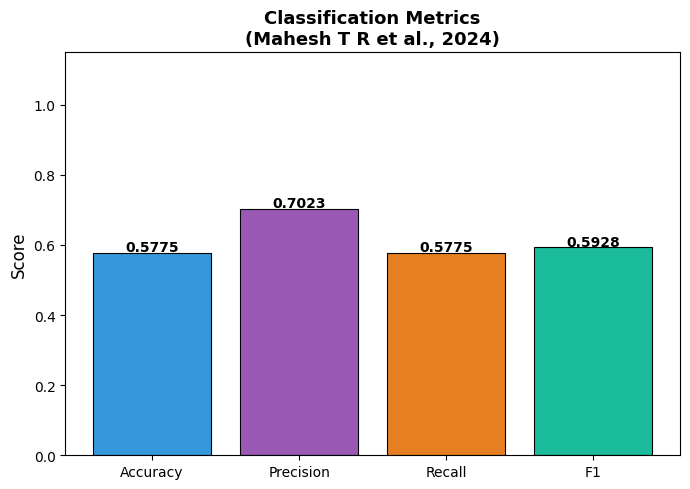

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/metric_classification.png


In [22]:
fig, ax = plt.subplots(figsize=(7, 5))
cls_metrics = ['Accuracy','Precision','Recall','F1']
cls_vals    = [acc, prec, rec, f1]
bars = ax.bar(cls_metrics, cls_vals, color=['#3498DB','#9B59B6','#E67E22','#1ABC9C'],
              edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, cls_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.4f}',
            ha='center', fontweight='bold', fontsize=10)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', fontsize=12)
ax.set_title('Classification Metrics\n(Mahesh T R et al., 2024)', fontsize=13, fontweight='bold')
plt.tight_layout()
out_path = os.path.join(XAI_DIR, 'metric_classification.png')
plt.savefig(out_path, dpi=150); plt.show()
print(f'✅ Disimpan: {out_path}')

In [ ]:
# ── Grafik gabungan semua metrik sekaligus (FINAL_5 style) ──────────────────
all_metric_names = ['Accuracy','Precision','Recall','F1']
all_metric_vals  = [acc, prec, rec, f1]
all_colors       = ['#3498DB','#9B59B6','#E67E22','#1ABC9C']

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(all_metric_names, all_metric_vals, color=all_colors, edgecolor='black', linewidth=0.8)
for bar, v in zip(bars, all_metric_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.3); ax.set_ylabel('Value / Score', fontsize=12)
ax.set_title('All Statistical Metrics — CNN Iftikhar 2025 + Grad-CAM++ XAI\n(Mahesh T R et al., 2024 — Section 3.5)',
             fontsize=13, fontweight='bold')
ax.axhline(1.0, linestyle='--', color='gray', alpha=0.4)
plt.tight_layout()
out_path = os.path.join(XAI_DIR, 'xai_statistical_metrics.png')
plt.savefig(out_path, dpi=150); plt.show()
print(f'✅ Disimpan: {out_path}')


## 13. Visualisasi Grad-CAM++ per Kuadran (TP / TN / FP / FN)

In [26]:
def make_mask_vis(img_rgb, mask):
    """Overlay mask kuning di atas gambar asli untuk visualisasi ground-truth."""
    vis = img_rgb.copy()
    if mask is not None and mask.sum() > 0:
        overlay = vis.copy()
        overlay[mask.astype(bool)] = [255, 230, 0]
        vis = cv2.addWeighted(vis.astype(np.float32), 0.5,
                               overlay.astype(np.float32), 0.5, 0).astype(np.uint8)
        contours, _ = cv2.findContours(mask.astype(np.uint8),
                                        cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(vis, contours, -1, (255, 200, 0), 2)
    return vis

def plot_quadrant_grid(indices, quadrant_name, quadrant_color,
                        n_show=4, alpha=0.5, save_dir=None):
    """Visualisasi 4-panel (Original / Heatmap / Mask / Overlay) per kuadran."""
    if len(indices) == 0:
        print(f'  ⚠️  Tidak ada gambar untuk kuadran {quadrant_name}.')
        return
    n = min(n_show, len(indices))
    selected = indices[:n]
    fig, axes = plt.subplots(n, 4, figsize=(20, 5*n))
    if n == 1: axes = axes[np.newaxis, :]

    for ax, t in zip(axes[0], ['🖼️ Original CT Scan', '🌡️ Grad-CAM++ Heatmap',
                                 '🎯 Ground-Truth Mask', '🔥 Overlay']):
        ax.set_title(t, fontsize=12, fontweight='bold', pad=8)

    for row_i, idx in enumerate(selected):
        img_rgb = test_imgs[idx]
        mask    = test_masks[idx]
        heatmap, overlay, pred_idx, pred_prob = gradcam_single(img_rgb, alpha=alpha)

        xalign_str = ''
        if mask is not None and test_labels[idx] == 1:
            sc = compute_xalign(heatmap, mask, XALIGN_ALPHA, XALIGN_BETA, XALIGN_GAMMA)
            xalign_str = (f'XAlign={sc["xalign"]:.3f}  '
                           f'WRO={sc["wro"]:.3f}  BAS={sc["bas"]:.3f}  DP={sc["dp"]:.3f}')

        row_label = (f'True: {CLASS_NAMES[test_labels[idx]]}\n'
                     f'Pred: {CLASS_NAMES[pred_idx]} ({pred_prob:.1%})')
        if xalign_str: row_label += f'\n{xalign_str}'

        axes[row_i, 0].set_ylabel(row_label, fontsize=9, rotation=0, labelpad=170, va='center')
        axes[row_i, 0].imshow(img_rgb); axes[row_i, 0].axis('off')

        im = axes[row_i, 1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[row_i, 1], fraction=0.046, pad=0.04)
        axes[row_i, 1].axis('off')

        axes[row_i, 2].imshow(make_mask_vis(img_rgb, mask)); axes[row_i, 2].axis('off')
        axes[row_i, 3].imshow(overlay); axes[row_i, 3].axis('off')

    sym = '✅' if quadrant_name in ('TP', 'TN') else '❌'
    fig.suptitle(f'{sym} Kuadran {quadrant_name} ({len(indices)} total — tampil {n})',
                 fontsize=15, fontweight='bold', color=quadrant_color, y=1.01)
    plt.tight_layout()
    if save_dir:
        out_path = os.path.join(save_dir, f'quadrant_{quadrant_name}.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'✅ Disimpan: {out_path}')
    plt.show()

print('✅ Fungsi make_mask_vis & plot_quadrant_grid siap.')

✅ Fungsi make_mask_vis & plot_quadrant_grid siap.


In [27]:
# ── Visualisasi 4-panel per kuadran ──────────────────────────────────────────
# ⚠️ test_masks belum ada sini — akan tersedia setelah Section 15 (load mask)
# Cell ini dipanggil ulang dengan data lengkap di Section 15b setelah mask dimuat

# Sementara: tampilkan tanpa mask (hanya untuk kuadran klasifikasi)
for quad_indices, quad_name, quad_color in [
    (tp_idx, 'TP', '#1A7F37'),
    (tn_idx, 'TN', '#1A7F37'),
    (fp_idx, 'FP', '#C0392B'),
    (fn_idx, 'FN', '#C0392B'),
]:
    if len(quad_indices) == 0:
        print(f'ℹ️  Tidak ada {quad_name}.')
        continue
    # Jalankan dengan test_masks placeholder (None) — mask akan di-overlay setelah Section 15
    n = min(4, len(quad_indices))
    selected = quad_indices[:n]
    fig, axes = plt.subplots(n, 3, figsize=(15, 5*n))
    if n == 1: axes = axes[np.newaxis, :]
    for ax, t in zip(axes[0], ['🖼️ Original CT Scan', '🌡️ Grad-CAM++ Heatmap', '🔥 Overlay']):
        ax.set_title(t, fontsize=12, fontweight='bold')
    for row_i, idx in enumerate(selected):
        img_rgb = test_imgs[idx]
        heatmap, overlay, pred_idx, pred_prob = gradcam_single(img_rgb, alpha=0.5)
        axes[row_i,0].set_ylabel(
            f'True: {CLASS_NAMES[test_labels[idx]]}\nPred: {CLASS_NAMES[pred_idx]} ({pred_prob:.1%})',
            fontsize=9, rotation=0, labelpad=155, va='center')
        axes[row_i,0].imshow(img_rgb); axes[row_i,0].axis('off')
        im=axes[row_i,1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[row_i,1], fraction=0.046); axes[row_i,1].axis('off')
        axes[row_i,2].imshow(overlay); axes[row_i,2].axis('off')
    sym = '✅' if quad_name in ('TP','TN') else '❌'
    fig.suptitle(f'{sym} Kuadran {quad_name} ({len(quad_indices)} total — tampil {n})',
                 fontsize=15, fontweight='bold', color=quad_color, y=1.01)
    plt.tight_layout()
    out_path = os.path.join(XAI_DIR, f'quadrant_{quad_name}.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✅ Disimpan: {out_path}')

Output hidden; open in https://colab.research.google.com to view.

## 14. Ekspor Saliency Map (.npy + metadata CSV)

Untuk setiap citra: simpan Grad-CAM++ saliency sebagai `.npy` + metadata CSV.
Output ini dibaca oleh notebook **8_xalign_evaluation_v2** (NB8).

In [28]:
for method in ['gradcam','gradcam_pp']:
    for cls in CLASS_NAMES:
        os.makedirs(os.path.join(SALIENCY_NPY_DIR, method, cls), exist_ok=True)

metadata_rows = []
skip_count    = 0

for img_path, true_cls, true_idx in tqdm(
        zip(test_paths, [CLASS_NAMES[l] for l in test_labels], test_labels),
        total=len(test_paths), desc='Ekspor saliency'):
    try:
        img_batch = preprocess_to_batch(img_path)
        preds     = model.predict(img_batch, verbose=0)[0]
        pred_idx  = int(np.argmax(preds))
        pred_cls  = CLASS_NAMES[pred_idx]
        pred_conf = float(preds[pred_idx])

        cam_gc,  _ = compute_gradcam(img_batch, pred_idx)
        cam_gcp, _ = compute_gradcam_plus_plus(img_batch, pred_idx)

        H, W = IMG_SIZE
        cam_gc_up  = cv2.resize(cam_gc,  (W,H), interpolation=cv2.INTER_LINEAR)
        cam_gcp_up = cv2.resize(cam_gcp, (W,H), interpolation=cv2.INTER_LINEAR)

        stem = Path(img_path).stem
        np.save(os.path.join(SALIENCY_NPY_DIR,'gradcam',    true_cls, f'{stem}.npy'), cam_gc_up.astype(np.float32))
        np.save(os.path.join(SALIENCY_NPY_DIR,'gradcam_pp', true_cls, f'{stem}.npy'), cam_gcp_up.astype(np.float32))

        metadata_rows.append({
            'image_path': img_path, 'stem': stem,
            'true_label': true_cls, 'true_idx': true_idx,
            'pred_label': pred_cls, 'pred_idx': pred_idx,
            'pred_conf': round(pred_conf, 6),
            'correct': int(pred_idx == true_idx),
            'saliency_gradcam_path':    os.path.join(SALIENCY_NPY_DIR,'gradcam',    true_cls, f'{stem}.npy'),
            'saliency_gradcam_pp_path': os.path.join(SALIENCY_NPY_DIR,'gradcam_pp', true_cls, f'{stem}.npy'),
        })
    except Exception as e:
        print(f'  ⚠️  Skip {img_path}: {e}'); skip_count += 1

fieldnames = ['image_path','stem','true_label','true_idx','pred_label','pred_idx',
              'pred_conf','correct','saliency_gradcam_path','saliency_gradcam_pp_path']
with open(METADATA_CSV, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader(); writer.writerows(metadata_rows)

n_ok = len(metadata_rows); n_all = len(test_paths)
acc_exp = sum(r['correct'] for r in metadata_rows)/n_ok*100 if n_ok else 0
print(f'\n✅ Ekspor selesai: {n_ok}/{n_all} | Akurasi: {acc_exp:.2f}%')
print(f'   Metadata CSV   : {METADATA_CSV}')
print(f'   Saliency .npy  : {SALIENCY_NPY_DIR}/')

Ekspor saliency:   0%|          | 0/142 [00:00<?, ?it/s]


✅ Ekspor selesai: 142/142 | Akurasi: 57.75%
   Metadata CSV   : /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/metadata_test.csv
   Saliency .npy  : /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/saliency_npy/


## 15. Implementasi XAlign (Muhammad & Bendechache 2025)

$$\text{XAlign} = \alpha \cdot \text{WRO} + \beta \cdot \text{BAS} - \gamma \cdot \text{DP}$$

In [29]:
def compute_wro(saliency_map, gt_mask):
    total = saliency_map.sum()
    if total < 1e-8: return 0.0
    return float((saliency_map * gt_mask).sum() / total)

def compute_bas(saliency_map, gt_mask, threshold=0.5):
    H, W = saliency_map.shape
    sal_bin = (saliency_map >= threshold).astype(np.uint8)
    gt_bin  = gt_mask.astype(np.uint8)
    c_sal, _ = cv2.findContours(sal_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    c_gt,  _ = cv2.findContours(gt_bin,  cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(c_sal) == 0 or len(c_gt) == 0: return 0.0
    pts_sal = np.vstack([c.reshape(-1,2) for c in c_sal]).astype(float)
    pts_gt  = np.vstack([c.reshape(-1,2) for c in c_gt ]).astype(float)
    hd = max(directed_hausdorff(pts_sal, pts_gt)[0], directed_hausdorff(pts_gt, pts_sal)[0])
    return float(np.clip(1.0 - hd/max(H,W), 0.0, 1.0))

def compute_dp(saliency_map, gt_mask):
    total = saliency_map.sum()
    if total < 1e-8: return 0.0
    return float((saliency_map * (1.0 - gt_mask)).sum() / total)

def compute_xalign(saliency_map, gt_mask, alpha=0.5, beta=0.4, gamma=0.1, threshold=0.5):
    s = saliency_map.astype(np.float32)
    if s.max() > 1.0+1e-6: s /= s.max()
    g = gt_mask.astype(np.float32)
    if s.shape != g.shape:
        g = cv2.resize(g, (s.shape[1], s.shape[0]), interpolation=cv2.INTER_NEAREST)
    g = (g > 0.5).astype(np.float32)
    wro = compute_wro(s, g); bas = compute_bas(s, g, threshold); dp = compute_dp(s, g)
    return {'wro': wro, 'bas': bas, 'dp': dp,
            'xalign': float(np.clip(alpha*wro + beta*bas - gamma*dp, 0.0, 1.0))}

print(f'✅ Fungsi XAlign siap.  α={XALIGN_ALPHA}, β={XALIGN_BETA}, γ={XALIGN_GAMMA}')

✅ Fungsi XAlign siap.  α=0.5, β=0.4, γ=0.1


## 16. Build Pair Table & Load Ground-Truth Mask

In [30]:
def build_pair_table(image_dir, mask_dir, split, image_pattern=None, mask_template=None):
    from pathlib import Path as _Path
    _pattern  = image_pattern if image_pattern is not None else IMAGE_PATTERN
    _template = mask_template if mask_template is not None else MASK_TEMPLATE
    image_dir = _Path(image_dir); mask_dir = _Path(mask_dir)
    records = []
    for img_path in sorted(image_dir.glob('*.png')):
        m = re.match(_pattern, img_path.name)
        if m is None: continue
        patient_id = m.group(1); slice_id = m.group(2)
        img_id    = f'{patient_id}_CT_s{slice_id}'
        mask_name = _template.format(patient_id=patient_id, slice_id=slice_id)
        msk_path  = mask_dir / mask_name
        records.append({'split': split, 'image_id': img_id, 'image_name': img_path.name,
                         'mask_name': mask_name, 'image_path': str(img_path),
                         'mask_path': str(msk_path), 'mask_exists': msk_path.is_file()})
    return pd.DataFrame(records)

PAIR_AVAILABLE = os.path.exists(PAIR_TEST_DIR) and os.path.exists(PAIR_TEST_MASK_DIR)

if PAIR_AVAILABLE:
    df_pair_test = build_pair_table(PAIR_TEST_DIR, PAIR_TEST_MASK_DIR, split='test')
    df_pair_val  = build_pair_table(PAIR_VAL_DIR,  PAIR_VAL_MASK_DIR,  split='val')
    df_pair_all  = pd.concat([df_pair_test, df_pair_val], ignore_index=True)
    n_valid = df_pair_all['mask_exists'].sum()
    print(f'✅ Pair Table: {len(df_pair_all)} total | {n_valid} mask valid')
    df_pair_all.to_csv(os.path.join(PAIR_OUTPUT_DIR, 'pair_table_all.csv'), index=False)
    df_pair_test.to_csv(os.path.join(PAIR_OUTPUT_DIR, 'pair_table_test.csv'), index=False)
    df_pair_val.to_csv(os.path.join(PAIR_OUTPUT_DIR, 'pair_table_val.csv'), index=False)
    pair_lookup = {row['image_name']: row['mask_path']
                   for _, row in df_pair_all.iterrows() if row['mask_exists']}
    MASKS_AVAILABLE = len(pair_lookup) > 0
else:
    pair_lookup = {}; MASKS_AVAILABLE = False
    print('⚠️  PAIR_TEST_DIR tidak ditemukan. XAlign akan dilewati.')

def load_gt_mask(img_path, pair_lookup, img_size=(224,224)):
    img_name = os.path.basename(img_path)
    if img_name in pair_lookup:
        mask_path = pair_lookup[img_name]
        if os.path.exists(mask_path):
            raw = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if raw is not None:
                return (cv2.resize(raw, img_size, interpolation=cv2.INTER_NEAREST) > 127).astype(np.float32)
    return None

test_masks = []
n_found    = 0
for fp in test_paths:
    mask = load_gt_mask(fp, pair_lookup, IMG_SIZE)
    test_masks.append(mask)
    if mask is not None: n_found += 1
print(f'Mask berhasil dimuat: {n_found} / {len(test_paths)}')

✅ Pair Table: 80 total | 80 mask valid
Mask berhasil dimuat: 41 / 142


### 16b. Visualisasi 4-Panel per Kuadran dengan Ground-Truth Mask

In [31]:
# Visualisasi ulang dengan mask penuh (4-panel: Original/Heatmap/Mask/Overlay)
if MASKS_AVAILABLE:
    for quad_indices, quad_name, quad_color in [
        (tp_idx, 'TP', '#1A7F37'),
        (tn_idx, 'TN', '#1A7F37'),
        (fp_idx, 'FP', '#C0392B'),
        (fn_idx, 'FN', '#C0392B'),
    ]:
        plot_quadrant_grid(quad_indices, quad_name, quad_color,
                           n_show=4, save_dir=XAI_DIR)
else:
    print('⚠️  Mask tidak tersedia — lewati visualisasi 4-panel.')

Output hidden; open in https://colab.research.google.com to view.

## 17. Hitung XAlign untuk Seluruh Test Images

In [32]:
xalign_results = []

if MASKS_AVAILABLE:
    print('Menghitung XAlign...')
    for i, (img_rgb, lbl, fp, mask) in enumerate(
            zip(test_imgs, test_labels, test_paths, test_masks)):
        if mask is None:
            xalign_results.append(None); continue
        img_batch = np.expand_dims(img_rgb.astype(np.float32)/255.0, 0)
        cam_gcp, _ = compute_gradcam_plus_plus(img_batch, lbl)
        heatmap_r  = cv2.resize(cam_gcp, IMG_SIZE)
        scores     = compute_xalign(heatmap_r, mask, XALIGN_ALPHA, XALIGN_BETA, XALIGN_GAMMA)
        pred_idx   = int(np.argmax(model.predict(img_batch, verbose=0)[0]))
        scores.update({'img_path': fp, 'cls_name': CLASS_NAMES[lbl],
                       'true_label': lbl, 'pred_label': pred_idx,
                       'pred_prob': float(model.predict(img_batch, verbose=0)[0][pred_idx]),
                       'correct': (lbl == pred_idx)})
        xalign_results.append(scores)
        if (i+1) % 10 == 0 or (i+1) == len(test_imgs):
            print(f'  [{i+1:3d}/{len(test_imgs)}] XAlign={scores["xalign"]:.4f}  WRO={scores["wro"]:.3f}  BAS={scores["bas"]:.3f}  DP={scores["dp"]:.3f}')
    valid_results = [r for r in xalign_results if r is not None]
    print(f'\n✅ XAlign dihitung untuk {len(valid_results)} gambar.')
else:
    valid_results = []
    print('⚠️  XAlign dilewati — mask tidak tersedia.')

Menghitung XAlign...
  [ 70/142] XAlign=0.0083  WRO=0.000  BAS=0.271  DP=1.000
  [ 80/142] XAlign=0.0384  WRO=0.000  BAS=0.346  DP=1.000
  [ 90/142] XAlign=0.0038  WRO=0.000  BAS=0.259  DP=1.000
  [100/142] XAlign=0.0150  WRO=0.000  BAS=0.287  DP=1.000

✅ XAlign dihitung untuk 41 gambar.


## 18. Statistik Dataset-Level XAlign

In [33]:
if valid_results:
    df_xalign = pd.DataFrame(valid_results)
    metrics_cols = ['xalign','wro','bas','dp']
    stats = df_xalign[metrics_cols].agg(['mean','std','min','max'])

    print('=' * 65)
    print('  Dataset-Level XAlign Statistics (Muhammad & Bendechache 2025)')
    print('=' * 65)
    print(f"  {'Metric':<10} {'Mean':>8} {'±SD':>8} {'Min':>8} {'Max':>8}")
    print('  ' + '-'*50)
    for col in metrics_cols:
        m = stats.loc['mean',col]; s = stats.loc['std',col]
        mn = stats.loc['min',col]; mx = stats.loc['max',col]
        print(f"  {col.upper():<10} {m:>8.4f} {s:>7.4f}  {mn:>8.4f} {mx:>8.4f}")
    print('=' * 65)

    print('\nXAlign per kelas:')
    print(df_xalign.groupby('cls_name')[metrics_cols].agg(['mean','std']).round(4))

    csv_path = os.path.join(XALIGN_DIR, 'xalign_per_image.csv')
    df_xalign.to_csv(csv_path, index=False)
    print(f'\n✅ Detail per gambar disimpan: {csv_path}')
else:
    print('⚠️  Tidak ada hasil XAlign.')

  Dataset-Level XAlign Statistics (Muhammad & Bendechache 2025)
  Metric         Mean      ±SD      Min      Max
  --------------------------------------------------
  XALIGN       0.0113  0.0146    0.0000   0.0439
  WRO          0.0000  0.0000    0.0000   0.0000
  BAS          0.2433  0.0786    0.0724   0.3597
  DP           1.0000  0.0000    1.0000   1.0000

XAlign per kelas:
          xalign          wro          bas           dp     
            mean     std mean  std    mean     std mean  std
cls_name                                                    
tumor     0.0113  0.0146  0.0  0.0  0.2433  0.0786  1.0  0.0

✅ Detail per gambar disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/xalign_per_image.csv


## 19. Visualisasi XAlign — Bar Chart & Histogram

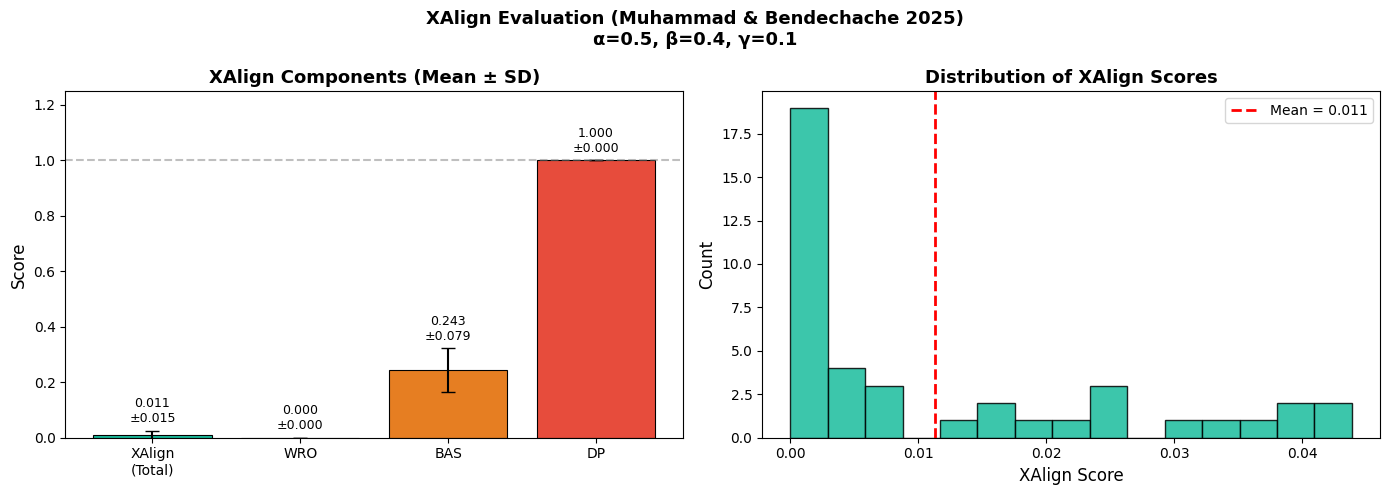

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/xalign_components.png


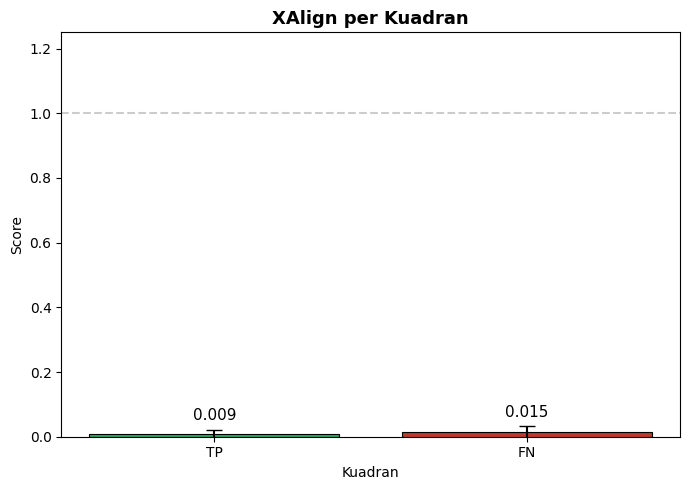

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/bar_xalign.png


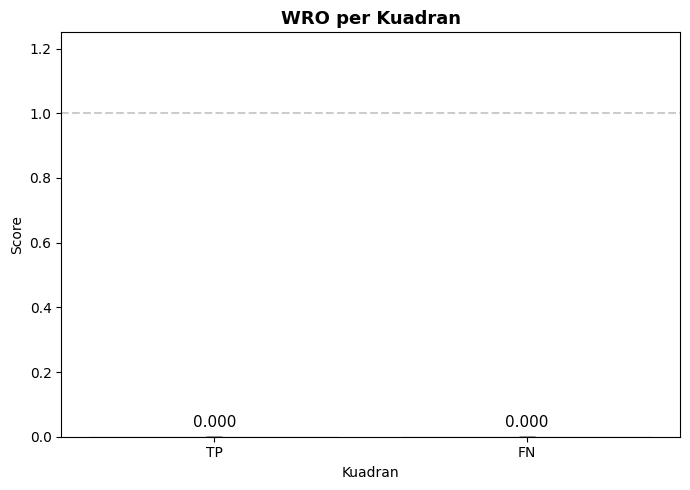

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/bar_wro.png


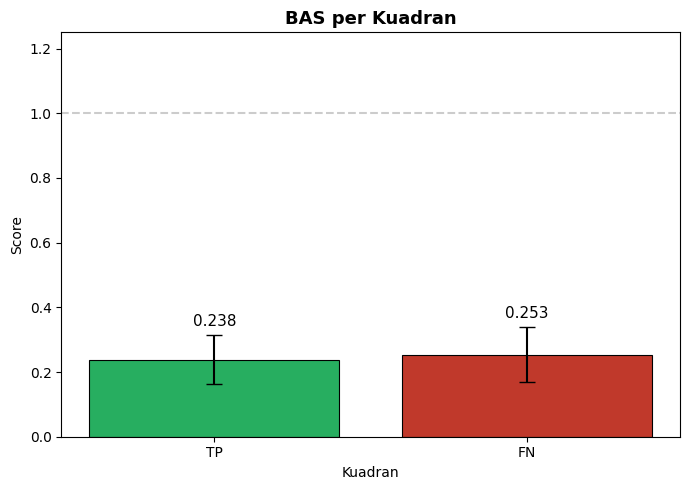

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/bar_bas.png


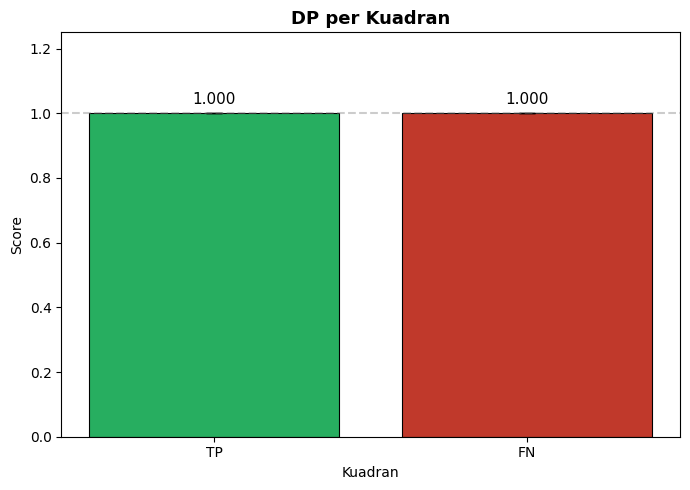

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/bar_dp.png


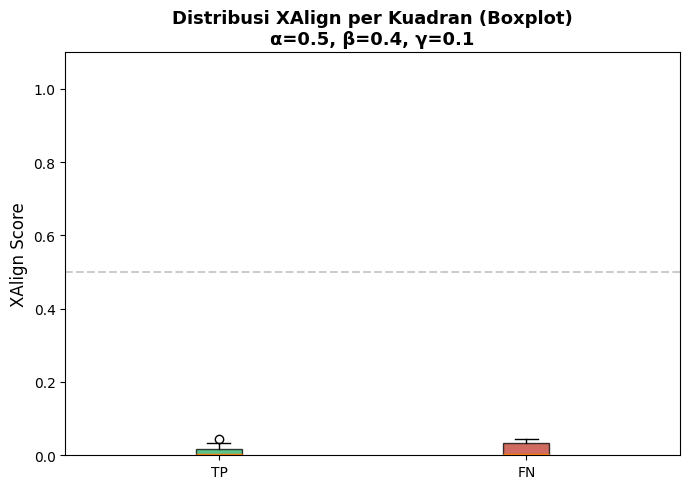

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/xalign_boxplot.png


In [34]:
if valid_results:
    df_xalign = pd.DataFrame(xalign_results) if 'df_xalign' not in dir() else df_xalign

    # ── 1. Bar chart komponen + histogram (FINAL_5 style) ────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    metric_labels = ['XAlign\n(Total)', 'WRO', 'BAS', 'DP']
    means  = [df_xalign[c].mean() for c in ['xalign','wro','bas','dp']]
    stds   = [df_xalign[c].std()  for c in ['xalign','wro','bas','dp']]
    colors_xa = ['#1ABC9C','#3498DB','#E67E22','#E74C3C']

    bars = axes[0].bar(metric_labels, means, yerr=stds, color=colors_xa,
                        edgecolor='black', linewidth=0.8, capsize=5)
    for bar, m, s in zip(bars, means, stds):
        axes[0].text(bar.get_x()+bar.get_width()/2, m+s+0.02,
                      f'{m:.3f}\n±{s:.3f}', ha='center', va='bottom', fontsize=9)
    axes[0].set_ylim(0, 1.25); axes[0].axhline(1.0, linestyle='--', color='gray', alpha=0.5)
    axes[0].set_ylabel('Score', fontsize=12)
    axes[0].set_title('XAlign Components (Mean ± SD)', fontsize=13, fontweight='bold')

    axes[1].hist(df_xalign['xalign'], bins=15, color='#1ABC9C', edgecolor='black', alpha=0.85)
    axes[1].axvline(df_xalign['xalign'].mean(), color='red', linestyle='--', linewidth=2,
                     label=f'Mean = {df_xalign["xalign"].mean():.3f}')
    axes[1].set_xlabel('XAlign Score', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Distribution of XAlign Scores', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=10)

    plt.suptitle(f'XAlign Evaluation (Muhammad & Bendechache 2025)\nα={XALIGN_ALPHA}, β={XALIGN_BETA}, γ={XALIGN_GAMMA}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    out_path = os.path.join(XALIGN_DIR, 'xalign_components.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight'); plt.show()
    print(f'✅ Disimpan: {out_path}')

    # ── 2. Bar chart per kuadran (FINAL_6 style) ─────────────────────────────
    quads_avail = [q for q in ['TP','FN','FP','TN'] if q in df_xalign.get('quadrant', pd.Series()).values]
    if not quads_avail and 'correct' in df_xalign.columns:
        # tambah kolom kuadran jika belum ada
        def _get_quad(row):
            tl,pl = int(row['true_label']), int(row['pred_label'])
            if tl==1 and pl==1: return 'TP'
            if tl==0 and pl==0: return 'TN'
            if tl==0 and pl==1: return 'FP'
            return 'FN'
        df_xalign['quadrant'] = df_xalign.apply(_get_quad, axis=1)
        quads_avail = [q for q in ['TP','FN','FP','TN'] if q in df_xalign['quadrant'].values]

    colors_quad = {'TP':'#27AE60','FN':'#C0392B','FP':'#E67E22','TN':'#2980B9'}
    for metric, metric_title in [('xalign','XAlign'),('wro','WRO'),('bas','BAS'),('dp','DP')]:
        means_q = [df_xalign[df_xalign['quadrant']==q][metric].mean() for q in quads_avail]
        stds_q  = [df_xalign[df_xalign['quadrant']==q][metric].std()  for q in quads_avail]
        colors_b = [colors_quad.get(q,'gray') for q in quads_avail]
        fig, ax = plt.subplots(figsize=(7, 5))
        ax.bar(quads_avail, means_q, yerr=stds_q, color=colors_b,
               edgecolor='black', capsize=6, linewidth=0.8)
        for j, (m, s) in enumerate(zip(means_q, stds_q)):
            s_val = s if not np.isnan(s) else 0
            ax.text(j, m+s_val+0.02, f'{m:.3f}', ha='center', va='bottom', fontsize=11)
        ax.set_title(f'{metric_title} per Kuadran', fontsize=13, fontweight='bold')
        ax.set_ylim(0, 1.25); ax.axhline(1.0, linestyle='--', color='gray', alpha=0.4)
        ax.set_xlabel('Kuadran'); ax.set_ylabel('Score')
        plt.tight_layout()
        out_path = os.path.join(XALIGN_DIR, f'bar_{metric}.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight'); plt.show()
        print(f'✅ Disimpan: {out_path}')

    # ── 3. Boxplot distribusi per kuadran ────────────────────────────────────
    data_box = [df_xalign[df_xalign['quadrant']==q]['xalign'].values for q in quads_avail]
    fig, ax = plt.subplots(figsize=(7, 5))
    bp = ax.boxplot(data_box, labels=quads_avail, patch_artist=True)
    for patch, q in zip(bp['boxes'], quads_avail):
        patch.set_facecolor(colors_quad.get(q,'gray')); patch.set_alpha(0.75)
    ax.set_ylabel('XAlign Score', fontsize=12)
    ax.set_title(f'Distribusi XAlign per Kuadran (Boxplot)\nα={XALIGN_ALPHA}, β={XALIGN_BETA}, γ={XALIGN_GAMMA}',
                 fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1); ax.axhline(0.5, linestyle='--', color='gray', alpha=0.4)
    plt.tight_layout()
    out_path = os.path.join(XALIGN_DIR, 'xalign_boxplot.png')
    plt.savefig(out_path, dpi=150); plt.show()
    print(f'✅ Disimpan: {out_path}')

## 20. Visualisasi Kualitatif — Top 4 Terbaik & Terburuk XAlign

In [35]:
def plot_xalign_topN(df_results, sort_by='xalign', ascending=False,
                      quadrant_filter=None, n=4, save_path=None):
    """Visualisasi 4-panel (Original/Heatmap/Mask/Overlay) top-N gambar."""
    df = df_results.copy()
    if quadrant_filter and 'quadrant' in df.columns:
        df = df[df['quadrant'] == quadrant_filter]
    df = df.sort_values(sort_by, ascending=ascending).head(n)
    if len(df) == 0:
        print(f'⚠️  Tidak ada data untuk filter={quadrant_filter}.')
        return

    fig, axes = plt.subplots(len(df), 4, figsize=(20, 5*len(df)))
    if len(df) == 1: axes = axes[np.newaxis, :]

    for ax, t in zip(axes[0], ['🖼️ Original CT Scan', '🌡️ Grad-CAM++ Heatmap',
                                 '🎯 Ground-Truth Mask', '🔥 Overlay + Skor']):
        ax.set_title(t, fontsize=12, fontweight='bold')

    for row_i, (_, row) in enumerate(df.iterrows()):
        try:
            gi = next(k for k, p in enumerate(test_paths) if p == row['img_path'])
        except StopIteration: continue
        img_rgb = test_imgs[gi]
        mask    = test_masks[gi] if gi < len(test_masks) else None
        heatmap, overlay, pred_idx, pred_prob = gradcam_single(img_rgb, alpha=0.5)
        mask_vis = make_mask_vis(img_rgb, mask)

        row_label = (f'True: {row["cls_name"]}\nPred: {CLASS_NAMES[int(row["pred_label"])]} ({pred_prob:.1%})\n'
                     f'XAlign={row["xalign"]:.4f}  WRO={row["wro"]:.3f}  BAS={row["bas"]:.3f}  DP={row["dp"]:.3f}')
        axes[row_i,0].set_ylabel(row_label, fontsize=8.5, rotation=0, labelpad=185, va='center')
        axes[row_i,0].imshow(img_rgb); axes[row_i,0].axis('off')

        im = axes[row_i,1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        plt.colorbar(im, ax=axes[row_i,1], fraction=0.046)
        axes[row_i,1].axis('off')

        axes[row_i,2].imshow(mask_vis); axes[row_i,2].axis('off')
        axes[row_i,3].imshow(overlay)
        quad = row.get('quadrant','')
        c = '#1A7F37' if quad in ('TP','TN') else '#C0392B'
        axes[row_i,3].set_title(f'{quad}  XAlign={row["xalign"]:.4f}', fontsize=10, color=c)
        axes[row_i,3].axis('off')

    direction = 'Tertinggi' if not ascending else 'Terendah'
    qstr = f'Kuadran {quadrant_filter} — ' if quadrant_filter else ''
    plt.suptitle(f'XAlign {qstr}Top-{n} {direction}\n(α={XALIGN_ALPHA}, β={XALIGN_BETA}, γ={XALIGN_GAMMA})',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'✅ Disimpan: {save_path}')
    plt.show()

print('✅ Fungsi plot_xalign_topN siap.')

✅ Fungsi plot_xalign_topN siap.


In [36]:
if valid_results:
    # ── Top-4 terbaik & terburuk XAlign — semua gambar ───────────────────────
    plot_xalign_topN(df_xalign, ascending=False, n=4,
                     save_path=os.path.join(XALIGN_DIR, 'xalign_top4_best.png'))
    plot_xalign_topN(df_xalign, ascending=True,  n=4,
                     save_path=os.path.join(XALIGN_DIR, 'xalign_top4_worst.png'))

    # ── Top-4 per kuadran (FINAL_6 style) ────────────────────────────────────
    if 'quadrant' in df_xalign.columns:
        plot_xalign_topN(df_xalign, quadrant_filter='TP', ascending=False, n=4,
                         save_path=os.path.join(XALIGN_DIR, 'xalign_TP_best.png'))
        if 'FN' in df_xalign['quadrant'].values:
            plot_xalign_topN(df_xalign, quadrant_filter='FN', ascending=True, n=4,
                             save_path=os.path.join(XALIGN_DIR, 'xalign_FN_worst.png'))
        else:
            print('ℹ️  Tidak ada FN — skip xalign_FN_worst.')
else:
    print('⚠️  Tidak ada hasil XAlign.')

Output hidden; open in https://colab.research.google.com to view.

## 21. Sensitivity Analysis XAlign terhadap Variasi Bobot

Sensitivity Analysis — Variasi Bobot XAlign
  Bobot (α,β,γ)              XAlign Mean  XAlign SD
  -------------------------------------------------------
  (0.6,0.3,0.1)                   0.0007     0.0019
  (0.5,0.4,0.1) [default]         0.0113     0.0145
  (0.4,0.4,0.2)                   0.0000     0.0000
  (0.3,0.5,0.2)                   0.0000     0.0000
  (0.2,0.6,0.2)                   0.0013     0.0038


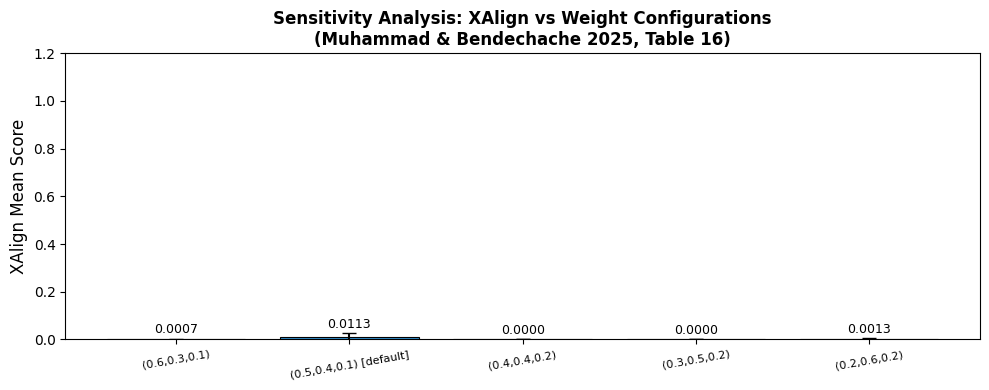

✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/xalign_sensitivity_weights.png
✅ Disimpan: /content/drive/MyDrive/Tugas Akhir/CNN Gradcam/Gradcam_GC_val_test/proses/gradcam_xai/xalign/xalign_sensitivity.png


In [37]:
if valid_results:
    weight_configs = [
        (0.6,0.3,0.1,'(0.6,0.3,0.1)'),
        (0.5,0.4,0.1,'(0.5,0.4,0.1) [default]'),
        (0.4,0.4,0.2,'(0.4,0.4,0.2)'),
        (0.3,0.5,0.2,'(0.3,0.5,0.2)'),
        (0.2,0.6,0.2,'(0.2,0.6,0.2)'),
    ]
    print('Sensitivity Analysis — Variasi Bobot XAlign')
    print('=' * 70)
    print(f"  {'Bobot (α,β,γ)':<25} {'XAlign Mean':>12} {'XAlign SD':>10}")
    print('  ' + '-'*55)
    sensitivity_data = []
    for alpha, beta, gamma, label in weight_configs:
        scores = [float(np.clip(alpha*r['wro'] + beta*r['bas'] - gamma*r['dp'], 0, 1))
                  for r in valid_results]
        m, s = np.mean(scores), np.std(scores)
        print(f"  {label:<25} {m:>12.4f} {s:>10.4f}")
        sensitivity_data.append({'config': label, 'mean': m, 'std': s})

    df_sens = pd.DataFrame(sensitivity_data)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(df_sens['config'], df_sens['mean'], yerr=df_sens['std'],
           color='#3498DB', edgecolor='black', capsize=5, linewidth=0.8)
    for i, (m, s) in enumerate(zip(df_sens['mean'], df_sens['std'])):
        ax.text(i, m+s+0.01, f'{m:.4f}', ha='center', va='bottom', fontsize=9)
    ax.set_ylabel('XAlign Mean Score', fontsize=12)
    ax.set_title('Sensitivity Analysis: XAlign vs Weight Configurations\n(Muhammad & Bendechache 2025, Table 16)',
                 fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.2); ax.tick_params(axis='x', labelsize=8, rotation=10)
    plt.tight_layout()
    out_path1 = os.path.join(XALIGN_DIR, 'xalign_sensitivity_weights.png')
    out_path2 = os.path.join(XALIGN_DIR, 'xalign_sensitivity.png')
    plt.savefig(out_path1, dpi=150); plt.savefig(out_path2, dpi=150)
    plt.show()
    print(f'✅ Disimpan: {out_path1}')
    print(f'✅ Disimpan: {out_path2}')

## 22. Simpan Ringkasan Metrik XAI (JSON)

In [ ]:
summary = {
    'model'           : 'CNN Iftikhar 2025 + Grad-CAM++ XAI',
    'reference_model' : 'Mahesh T R et al. (2024)',
    'reference_xalign': 'Muhammad D & Bendechache M (2025) — Front. Med. Technol. 7:1674343',
    'gradcam_layer'   : LAST_CONV_LAYER,
    'accuracy'        : round(float(acc),  6),
    'precision'       : round(float(prec), 6),
    'recall'          : round(float(rec),  6),
    'f1_score'        : round(float(f1),   6),
    'xalign_enabled'  : MASKS_AVAILABLE,
    'xalign_alpha'    : XALIGN_ALPHA,
    'xalign_beta'     : XALIGN_BETA,
    'xalign_gamma'    : XALIGN_GAMMA,
    'xalign_n_images' : len(valid_results) if valid_results else 0,
}
if valid_results:
    for col in ['xalign','wro','bas','dp']:
        summary[f'{col}_mean'] = round(float(df_xalign[col].mean()), 6)
        summary[f'{col}_std' ] = round(float(df_xalign[col].std()),  6)

summary_path = os.path.join(XAI_DIR, 'xai_summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('=== Ringkasan Metrik XAI + XAlign ===')
print(json.dumps(summary, indent=2))
print(f'\n✅ Disimpan ke: {summary_path}')
print(f'\n📁 Output tersimpan di:')
print(f'   XAI     : {XAI_DIR}')
print(f'   XAlign  : {XALIGN_DIR}')
print(f'   Saliency: {SALIENCY_NPY_DIR}')
